# Lab 1: Stats!

This is the start of Lab 1 in this notebook! We will start by investigating the good old Normal distribution and the Z-values associated with its probabilities (and vice-versa). And then we will extend these techniques to other (continuous) distributions.

In [59]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from scipy.stats import norm
from scipy.stats import expon
import math

# The Normal Distribution

First let's plot the standard Gaussian (centered at 0 with variance 1):

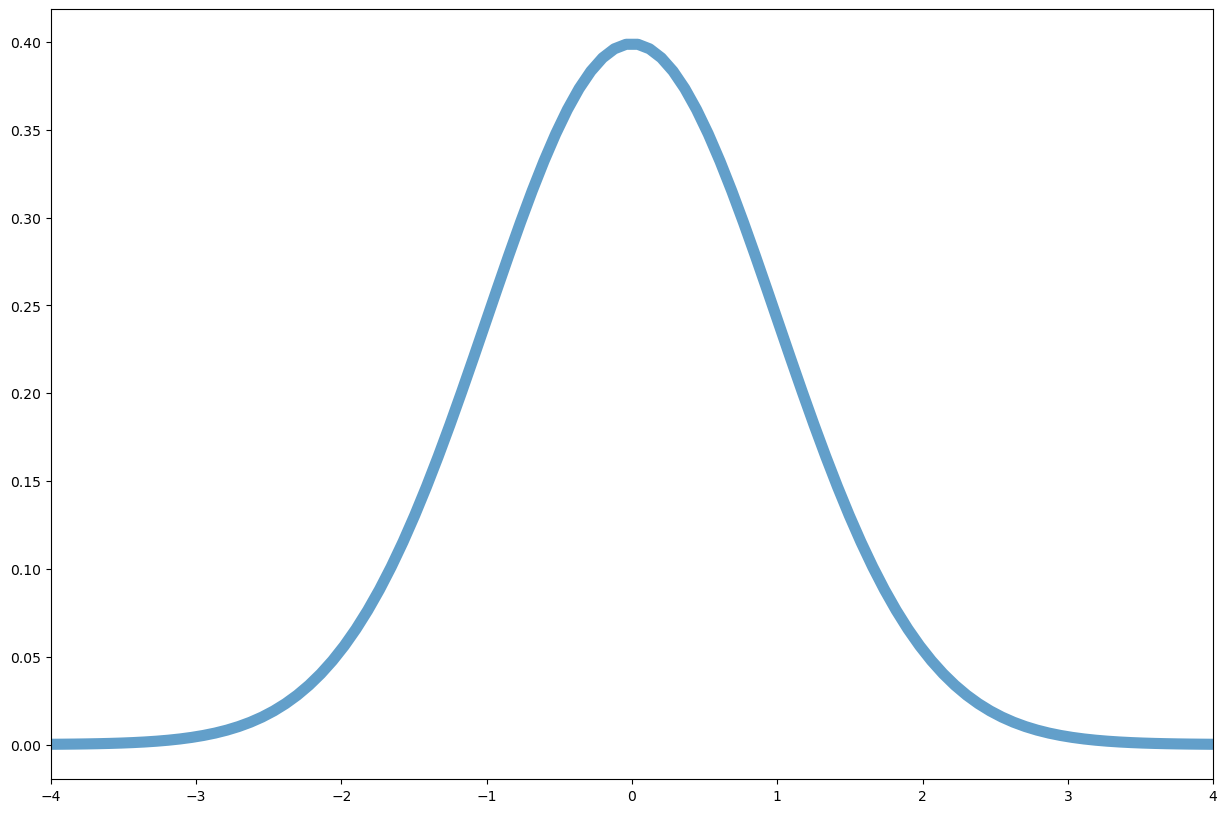

In [41]:
fig, ax = plt.subplots(1, 1)
plt.xlim([-4,4])
x = np.linspace(-4,4,100)
ax.plot(x,stats.norm.pdf(x,loc = 0., scale = 1),linewidth = 8,alpha = 0.7)
plt.show()

We will now take integrals of this distribution for the three sigmas $$ \sigma, 0.5\sigma, 2\sigma $$, for which we should get probabilities $$ (0.84134, 0.69146, 0.97725) $$.

In [33]:
# Setting the parameters of our Gaussian
mean = 0
std_dev = 1

# For one standard deviation out
z = 1
cdf_value = norm.cdf(z, loc=mean, scale=std_dev)
print(f"The probability corresponding to measuring one sigma or less is: {cdf_value}")

# For half a standard deviation out
z = 0.5
cdf_value = norm.cdf(z, loc=mean, scale=std_dev)
print(f"The probability corresponding to measuring half a sigma or less is: {cdf_value}")

# For two standard deviations out
z = 2
cdf_value = norm.cdf(z, loc=mean, scale=std_dev)
print(f"The probability corresponding to measuring two sigmas or less is: {cdf_value}")

The probability corresponding to measuring one sigma or less is: 0.8413447460685429
The probability corresponding to measuring half a sigma or less is: 0.6914624612740131
The probability corresponding to measuring two sigmas or less is: 0.9772498680518208


Now we do the reverse--which involves finding the sigma associated with a given probability. For the sake of ease, we will simply invert the last step.

In [34]:
# Setting the parameters of our Gaussian
mean = 0
std_dev = 1

# For probability of measuring this sigma (or less) being 0.84134
p = 0.84134
ppf_value = norm.ppf(p, loc=mean, scale=std_dev)
print(f"The z-value corresponding to the probability 0.84: {round(ppf_value, 1)}")

# For probability of measuring this sigma (or less) being 0.69146
p = 0.69146
ppf_value = norm.ppf(p, loc=mean, scale=std_dev)
print(f"The z-value corresponding to the probability 0.69: {round(ppf_value, 1)}")

# For probability of measuring this sigma (or less) being 0.97725
p = 0.97725
ppf_value = norm.ppf(p, loc=mean, scale=std_dev)
print(f"The z-value corresponding to the probability 0.97: {round(ppf_value, 1)}")

The z-value corresponding to the probability 0.84: 1.0
The z-value corresponding to the probability 0.69: 0.5
The z-value corresponding to the probability 0.97: 2.0


As an aside, if a negative z-value had appeared, this would simply mean that this probability corresponded to the probability measuring something lesser than the mean (ie the cdf had as input a negative number)!

# The Exponential Distribution

The exponential distribution is the continuous relaxation of the geometric distribution--In some sense it gives us the probability of an event happening (in continuous time) after a certain number of time steps. It is memoryless and the reason the PDF looks looks like an exponentially decaying curve is simply due to independence implying that probability of the event not happening compounding.

In [35]:
# Pick the parameter for the dist
lda = 0.5

# Sample points
dis = stats.expon.rvs(scale = 1 / lda, size = 1000000)

Now let's plot the exponential distribution (both in the analytic form and as a histogram of rvs sampled from it)

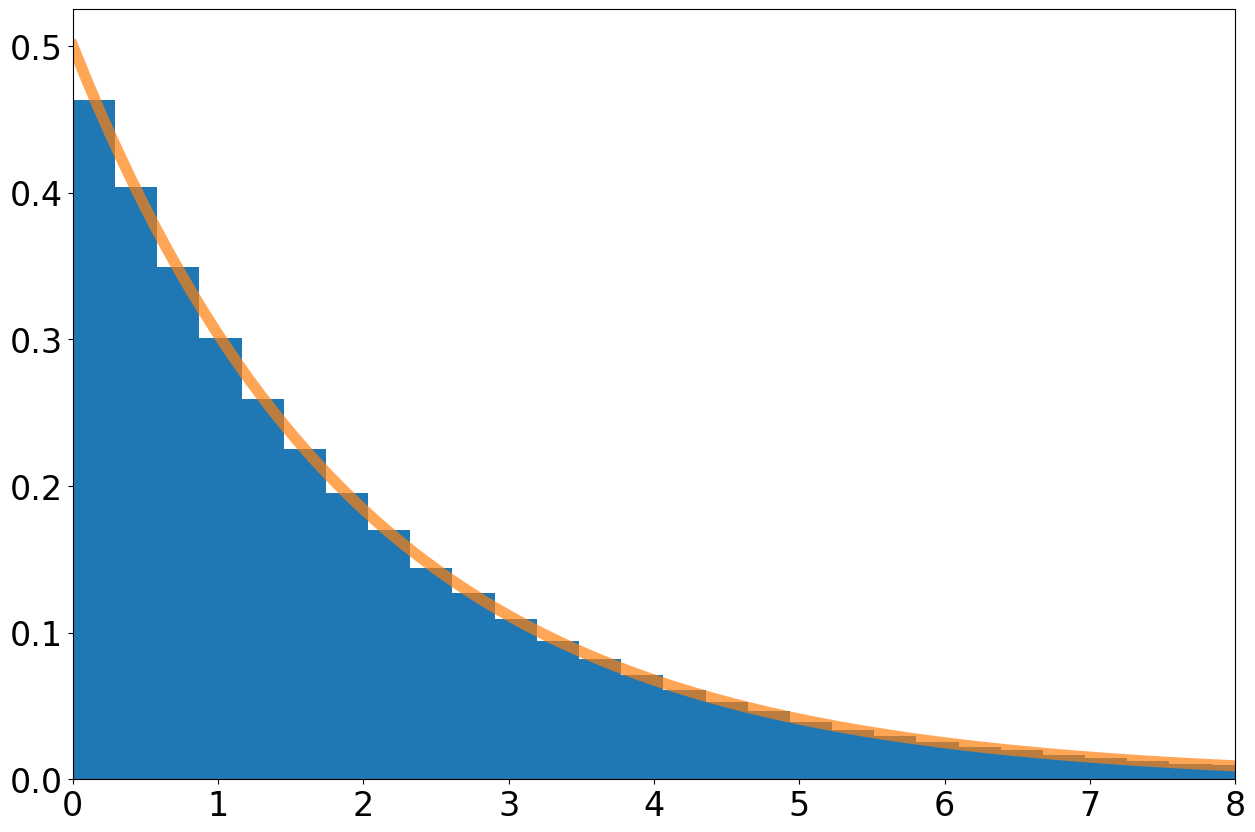

In [40]:
fig, ax = plt.subplots(1, 1)
ax.hist(dis,100, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([0,8])
x = np.linspace(0,8,100)
ax.plot(x,stats.expon.pdf(x, scale = 2),linewidth = 8,alpha = 0.7)
plt.show()

# Radioactive decay

A radioactive nucleus really is memoryless (in the sense that the probability it decays in a single time step is the same no matter the starting time) and we are modelling the probability that a single nucleus hasn't decayed by this exponential distribution. 

# Setup and question

Imagine we have a geiger counter (that clicks when the nucleus decays) and stopwatch. Say the counter clicks at some time T. We would like to compute the probability of the nucleus having decayed by that certain time and reason how much longer from expectation it took for that nucleus to decay.

We first note that the probability that the nucleus decays by time T, is given by the following CDF:

$$ \mathbb{P}(t_d \le T) = \int_0 ^ T \lambda e^{-\lambda x} dx $$

We will now compute this probability for times 1, 2, 4, and 8--while stating their appropriate sigma values.

In [51]:
# Setting the parameters of our Exponential
lda = 0.5
mean = 1/lda

In [53]:
# For T = 1
T = 1
cdf_value = expon.cdf(T, scale= 1 / lda)
ppf_value = expon.ppf(cdf_value, scale= 1 / lda)
# Computing the number of sigmas we're out by, which is the number of standard deviations away from the mean we are
sigma = abs(ppf_value - mean) * lda
print(f"The probability of the particle decay at or under 1 second is: {cdf_value}")
print(f"The sigma corresponding to the particle decaying in a second or less is: {round(sigma, 2)}")

The probability of the particle decay at or under 1 second is: 0.3934693402873666
The sigma corresponding to the particle decaying in a second or less is: 0.5


In [54]:
# For T = 2
T = 2
cdf_value = expon.cdf(T, scale= 1 / lda)
ppf_value = expon.ppf(cdf_value, scale= 1 / lda)
# Computing the number of sigmas we're out by, which is the number of standard deviations away from the mean we are
sigma = abs(ppf_value - mean) * lda  
print(f"The probability of the particle decay at or under 2 seconds is: {cdf_value}")
print(f"The sigma corresponding to the particle decaying in 2 seconds or less is: {round(sigma, 2)}")

The probability of the particle decay at or under 2 seconds is: 0.6321205588285577
The sigma corresponding to the particle decaying in 2 seconds or less is: 0.0


In [55]:
# For T = 4
T = 4
cdf_value = expon.cdf(T, scale= 1 / lda)
ppf_value = expon.ppf(cdf_value, scale= 1 / lda)
# Computing the number of sigmas we're out by, which is the number of standard deviations away from the mean we are
sigma = abs(ppf_value - mean) * lda  
print(f"The probability of the particle decay at or under 4 seconds is: {cdf_value}")
print(f"The sigma corresponding to the particle decaying in 4 seconds or less is: {round(sigma, 2)}")

The probability of the particle decay at or under 4 seconds is: 0.8646647167633873
The sigma corresponding to the particle decaying in 4 seconds or less is: 1.0


In [56]:
# For T = 8
T = 8
cdf_value = expon.cdf(T, scale= 1 / lda)
ppf_value = expon.ppf(cdf_value, scale= 1 / lda)
# Computing the number of sigmas we're out by, which is the number of standard deviations away from the mean we are
sigma = abs(ppf_value - mean) * lda  
print(f"The probability of the particle decay at or under 8 seconds is: {cdf_value}")
print(f"The sigma corresponding to the particle decaying in 8 seconds or less is: {round(sigma, 2)}")

The probability of the particle decay at or under 8 seconds is: 0.9816843611112658
The sigma corresponding to the particle decaying in 8 seconds or less is: 3.0


And we're done! We can now see how likely it is for a particle to decay at certain, and how far from our expectation it is! Having explored different measurement values, it is clear that the probability we don't measure decay exponentially decays with time. This is in line with the results of from nuclear physics! A way to see this is from half life. Nuclear physics tell us that the half life is given by:

$$ t_H = \frac{\ln 2}{\lambda} $$

And if we in fact extract the ppf value for a probability of 0.5:

In [57]:
ppf_value = expon.ppf(0.5, scale= 1 / lda)
print(f"The time it takes for the particle to have a 50% chance of decaying is: {round(ppf_value, 2)}")

The time it takes for the particle to have a 50% chance of decaying is: 1.39


In [61]:
half_life = math.log(2) / lda
print(f"The theoretical prediction for half life is: {round(half_life, 2)}")

The theoretical prediction for half life is: 1.39


Our results line up! This process is in fact in line with the Physics we know :)